# Student Pass/Fail Prediction — Exploratory Data Analysis

Predict whether a student passes their final exam (G3 >= 10) using the UCI Student Performance dataset (1,044 students from two schools, covering math and portuguese courses, with demographic, family, and behavioral features). Final grades G1, G2, G3 are dropped to avoid leakage — the model relies on contextual signals only.

**Target:** `passed` (0 = Fail, 1 = Pass)

## 1. Imports & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings; warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
%matplotlib inline

In [2]:
df = pd.read_csv('data/student.csv')
# Drop G1, G2, G3 to avoid leakage — keep only behavioral / demographic features.
leakage = [c for c in ['G1', 'G2', 'G3'] if c in df.columns]
df = df.drop(columns=leakage)
print('Shape:', df.shape)
df.head()

Shape: (1044, 32)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,course,passed
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,math,0
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,math,0
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,math,1
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,math,1
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,math,1


## 2. Dataset Overview

In [3]:
print('Shape:', df.shape)
print('\nDtypes:')
print(df.dtypes.value_counts())

Shape: (1044, 32)

Dtypes:
object    18
int64     14
Name: count, dtype: int64


In [4]:
df.describe(include='all').T.head(20)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
school,1044,2,GP,772,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,1044,2,F,591,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,1044.0,NaN,NaN,NaN,16.726054,1.239975,15.0,16.0,17.0,18.0,22.0
address,1044,2,U,759,NaN,NaN,NaN,NaN,NaN,NaN,NaN
famsize,1044,2,GT3,738,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pstatus,1044,2,T,923,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Medu,1044.0,NaN,NaN,NaN,2.603448,1.124907,0.0,2.0,3.0,4.0,4.0
Fedu,1044.0,NaN,NaN,NaN,2.387931,1.099938,0.0,1.0,2.0,3.0,4.0
Mjob,1044,5,other,399,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fjob,1044,5,other,584,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
print('Duplicate rows:', df.duplicated().sum())
print('Memory (MB):', round(df.memory_usage(deep=True).sum() / 1024**2, 2))

Duplicate rows: 0
Memory (MB): 1.05


## 3. Missing / Invalid Values

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Percent': missing_pct})
missing_df = missing_df[missing_df['Missing'] > 0].sort_values('Missing', ascending=False)
if len(missing_df):
    print(missing_df)
else:
    print('No explicit NaN values')

No explicit NaN values


## 4. Target Variable Distribution

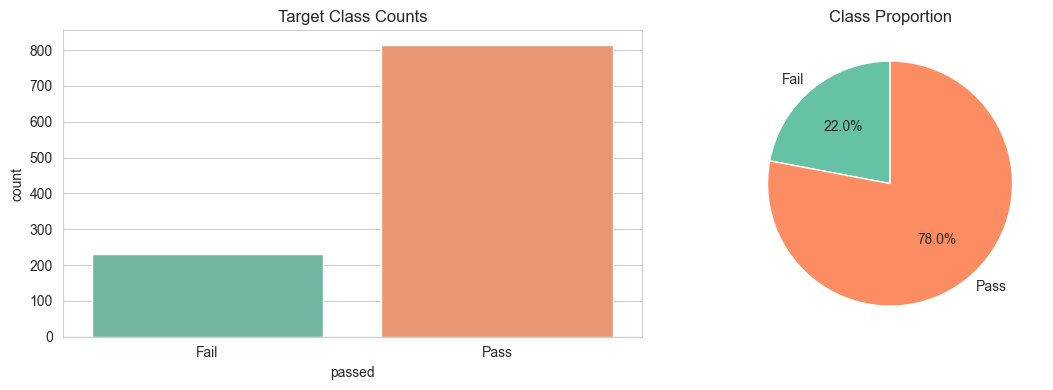


Class balance (%):
passed
0    22.03
1    77.97
Name: count, dtype: float64


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
target_counts = df['passed'].value_counts().sort_index()
sns.countplot(x='passed', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Target Class Counts')
axes[0].set_xticklabels(['Fail', 'Pass'])
axes[1].pie(target_counts, labels=['Fail', 'Pass'], autopct='%1.1f%%',
            colors=['#66c2a5', '#fc8d62'], startangle=90)
axes[1].set_title('Class Proportion')
plt.tight_layout(); plt.show()
print('\nClass balance (%):')
print((target_counts / target_counts.sum() * 100).round(2))

## 5. Univariate Analysis — Numeric Features

In [8]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'passed' in numeric_cols:
    numeric_cols.remove('passed')
print(f'Numeric features ({len(numeric_cols)}):')
print(numeric_cols)

Numeric features (13):
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']


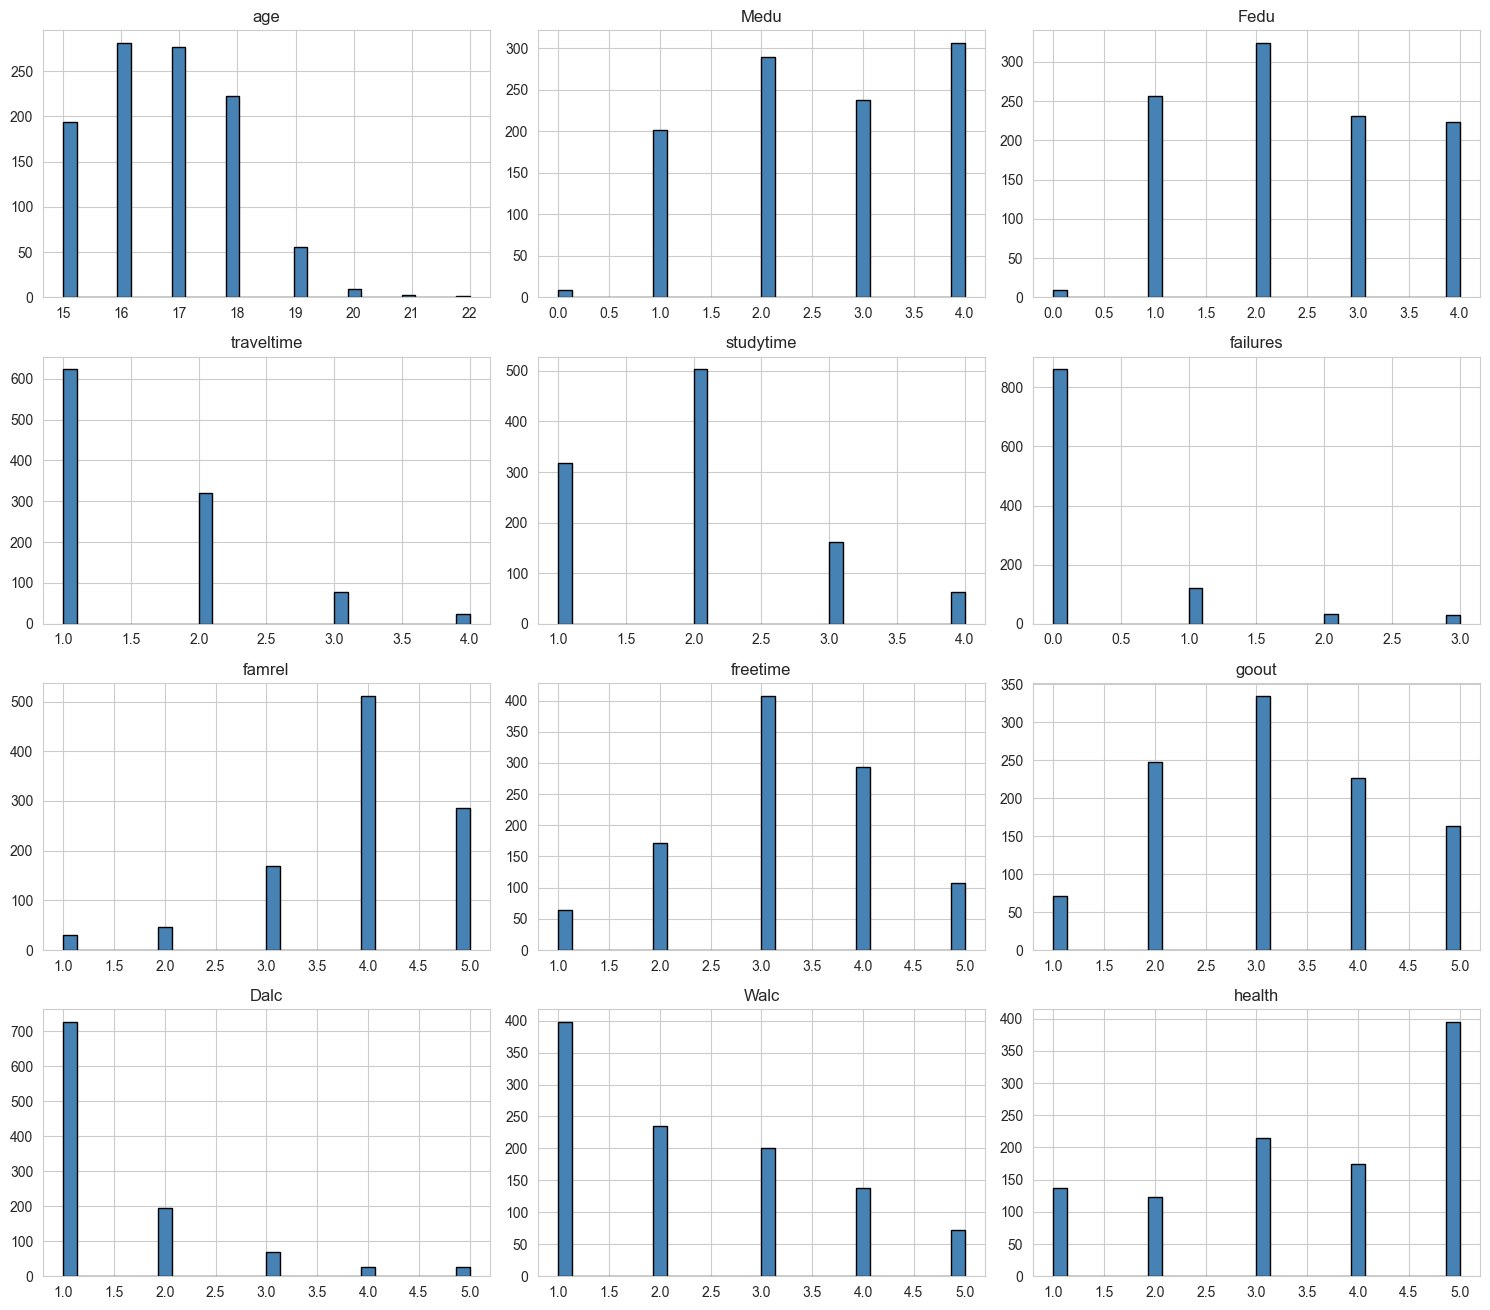

In [9]:
import math
n_show = min(len(numeric_cols), 12)
ncols = 3
nrows = math.ceil(n_show / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.3*nrows))
axes = np.array(axes).reshape(-1)
for i, col in enumerate(numeric_cols[:n_show]):
    df[col].hist(ax=axes[i], bins=30, color='steelblue', edgecolor='black')
    axes[i].set_title(col)
for j in range(n_show, len(axes)):
    axes[j].axis('off')
plt.tight_layout(); plt.show()

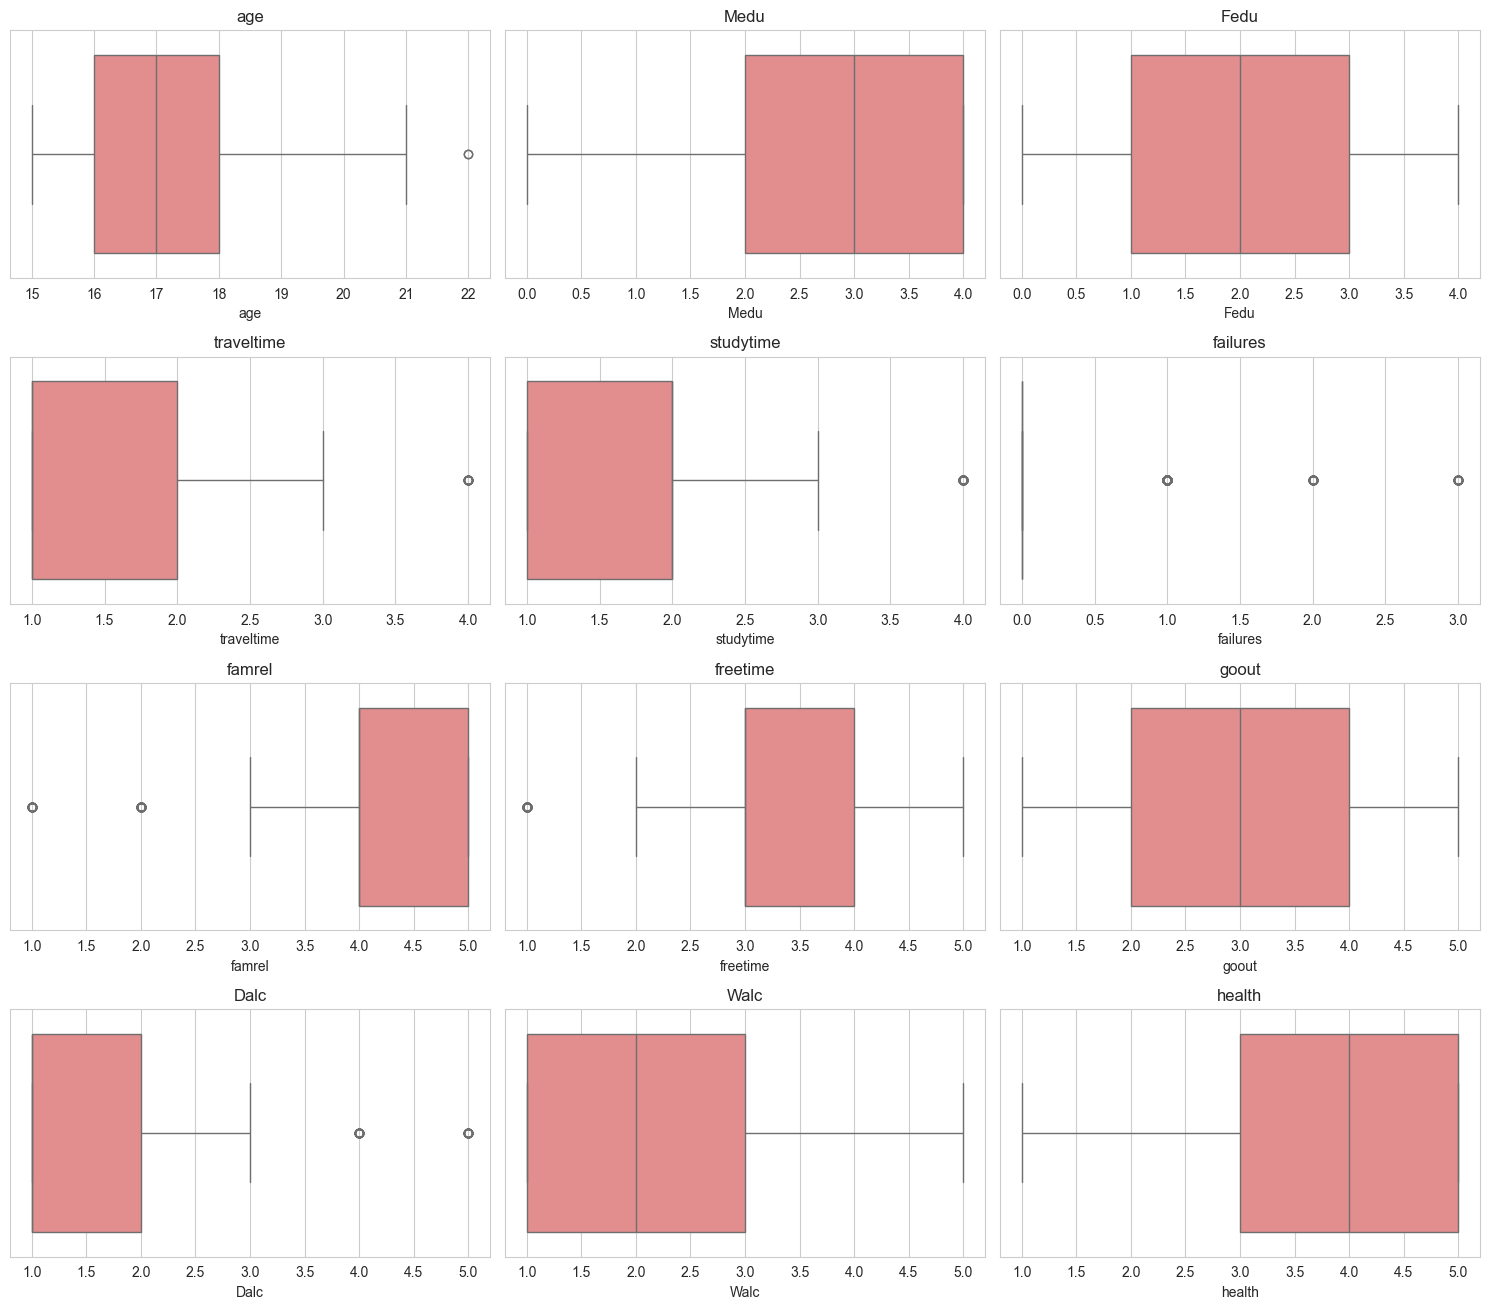

In [10]:
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.3*nrows))
axes = np.array(axes).reshape(-1)
for i, col in enumerate(numeric_cols[:n_show]):
    sns.boxplot(x=df[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(col)
for j in range(n_show, len(axes)):
    axes[j].axis('off')
plt.tight_layout(); plt.show()

## 6. Bivariate Analysis — Features vs Target

In [11]:
corrs_all = df[numeric_cols + ['passed']].corr()['passed'].abs().sort_values(ascending=False)
top_features = [c for c in corrs_all.index if c != 'passed'][:6]
print('Top features by |correlation| with target:')
print(corrs_all[top_features].round(3))

Top features by |correlation| with target:
failures     0.367
age          0.134
absences     0.119
studytime    0.109
goout        0.107
Medu         0.106
Name: passed, dtype: float64


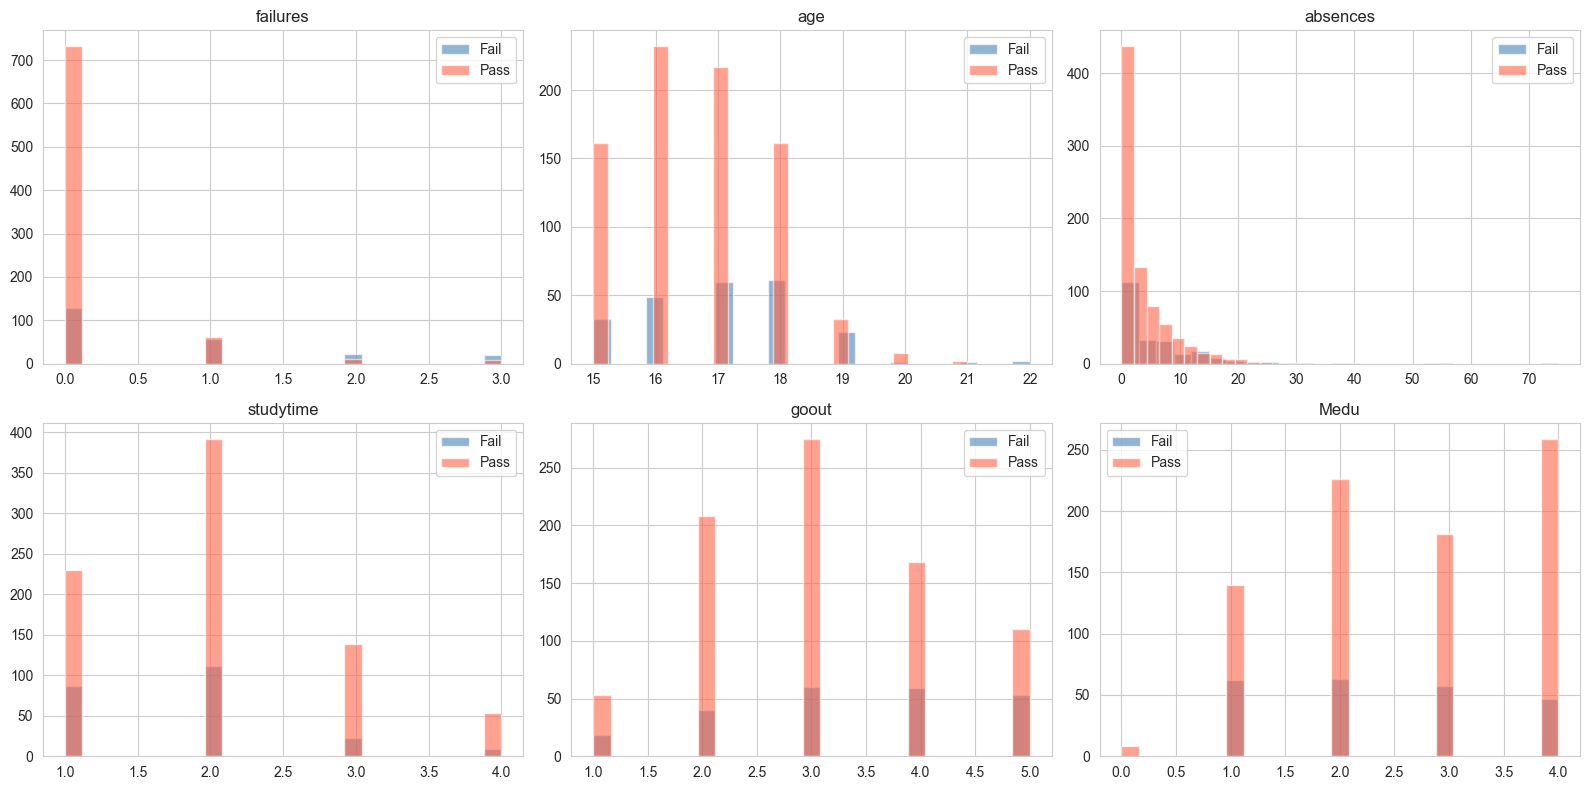

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
labels = ['Fail', 'Pass']
colors = ['steelblue', 'tomato']
for i, col in enumerate(top_features[:6]):
    for cls, lbl, c in [(0, labels[0], colors[0]), (1, labels[1], colors[1])]:
        axes[i].hist(df[df['passed']==cls][col].dropna(), bins=25, alpha=0.6, label=lbl, color=c)
    axes[i].set_title(col); axes[i].legend()
plt.tight_layout(); plt.show()

In [13]:
means = df.groupby('passed')[numeric_cols].mean().T
means.columns = ['Fail', 'Pass']
means['Difference'] = means.iloc[:, 1] - means.iloc[:, 0]
means.sort_values('Difference', key=abs, ascending=False).round(3).head(15)

,Fail,Pass,Difference
absences,5.826,4.042,-1.784
failures,0.717,0.136,-0.581
age,17.039,16.638,-0.402
goout,3.387,3.091,-0.296
Medu,2.378,2.667,0.289
Fedu,2.170,2.450,0.280
Walc,2.470,2.232,-0.237
studytime,1.800,2.018,0.218
Dalc,1.648,1.451,-0.197
freetime,3.326,3.166,-0.160


## 7. Correlation Analysis

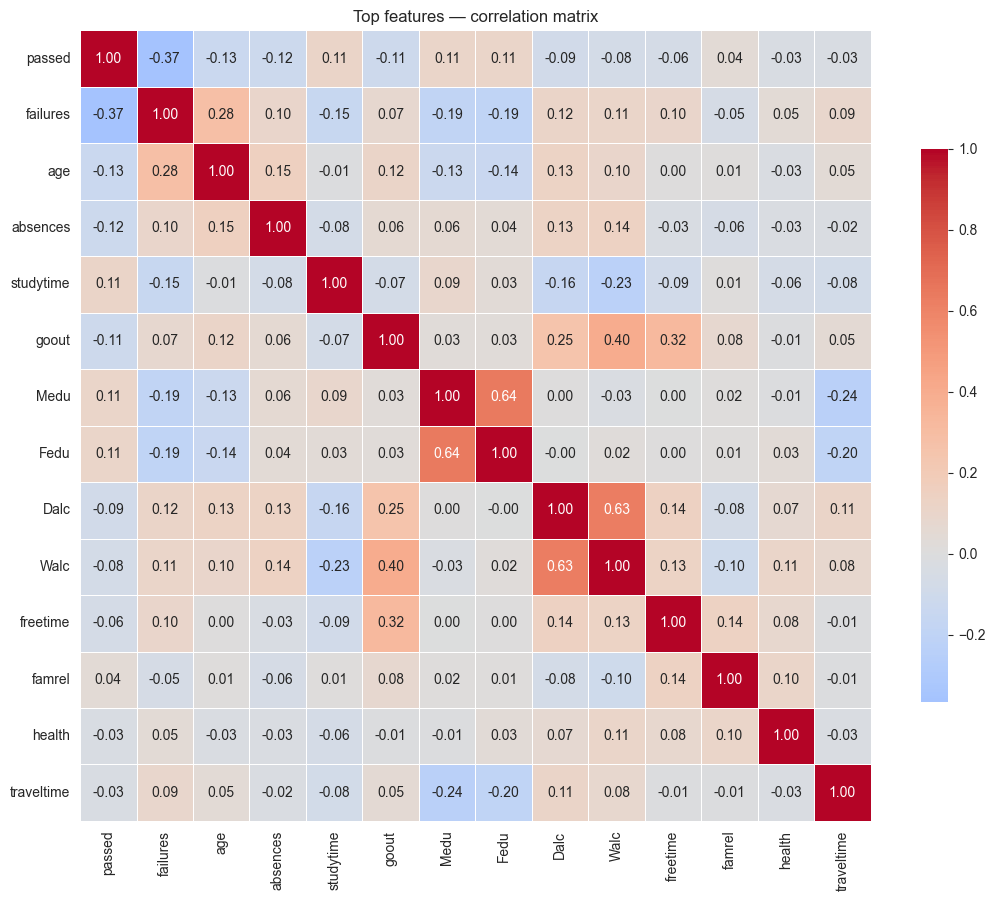

In [14]:
# Restrict to top numeric features for legibility
top_numeric = corrs_all.head(15).index.tolist()
if 'passed' not in top_numeric:
    top_numeric.append('passed')
corr_matrix = df[top_numeric].corr()
plt.figure(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.7})
plt.title('Top features — correlation matrix'); plt.tight_layout(); plt.show()

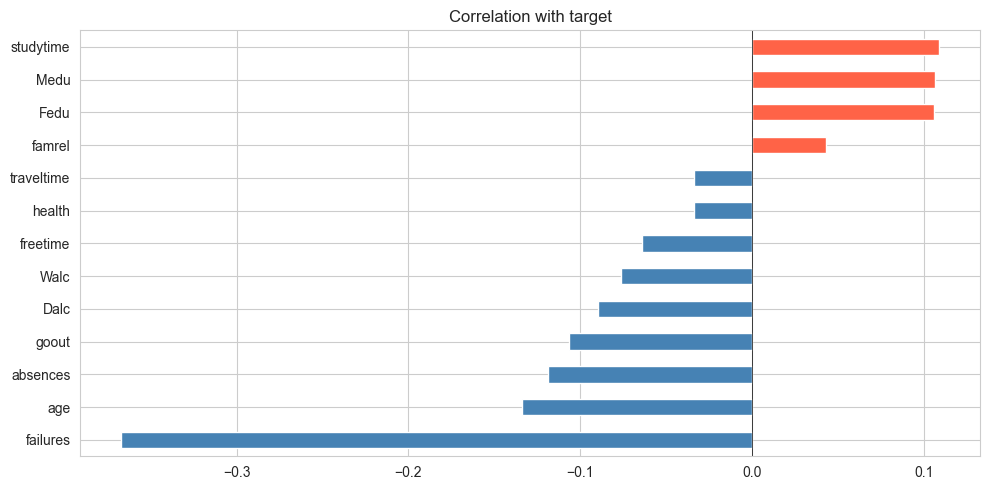

In [15]:
target_corr = df[numeric_cols + ['passed']].corr()['passed'].drop('passed').sort_values()
plt.figure(figsize=(10, max(5, len(target_corr)*0.25)))
colors = ['tomato' if v > 0 else 'steelblue' for v in target_corr]
target_corr.plot(kind='barh', color=colors)
plt.title('Correlation with target')
plt.axvline(0, color='black', linewidth=0.5)
plt.tight_layout(); plt.show()

## 8. Domain Deep-Dive — Behavioural & Family Drivers

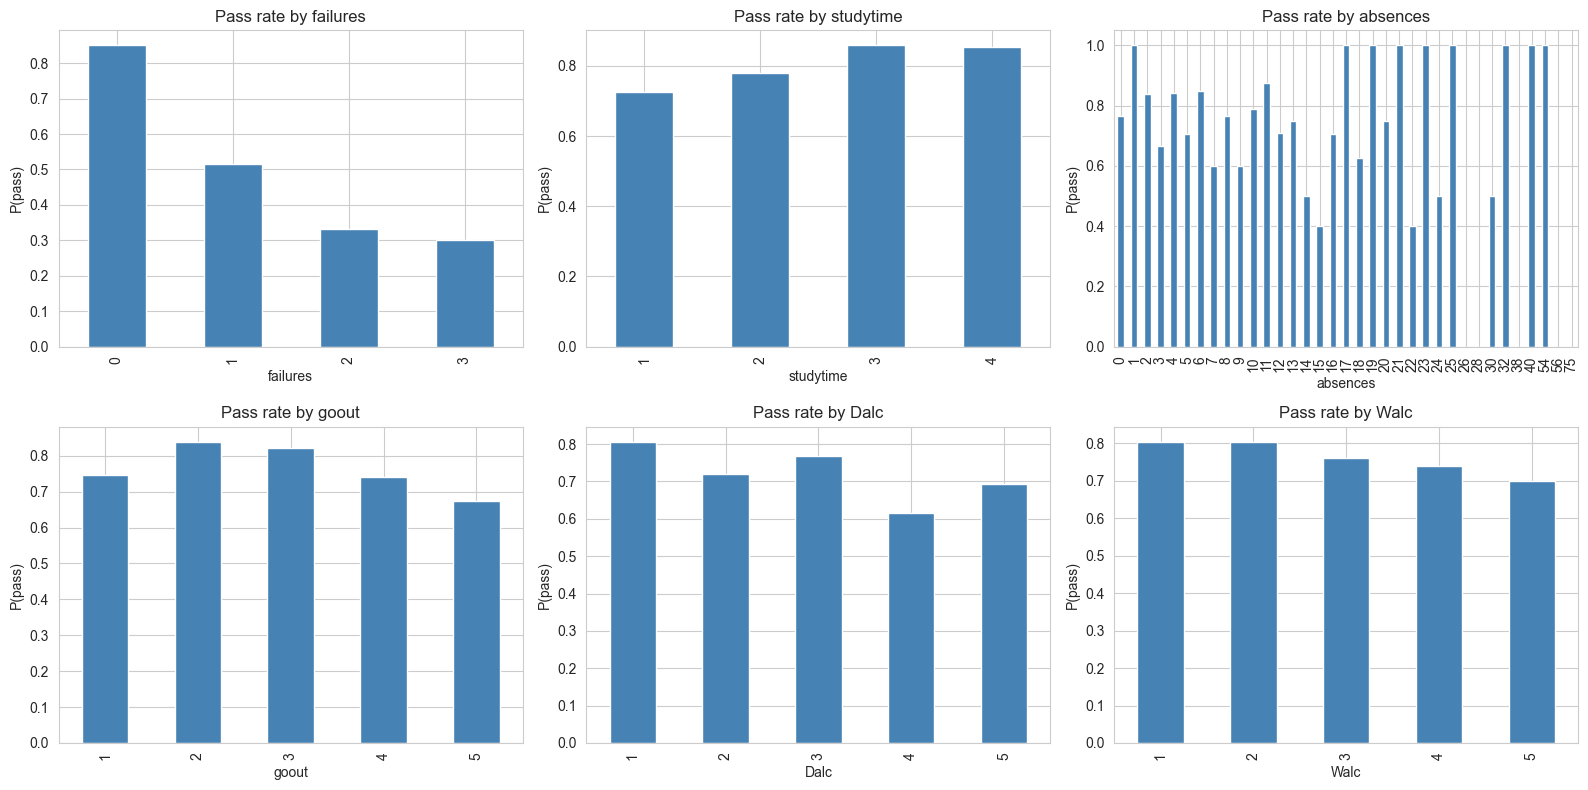

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(['failures', 'studytime', 'absences', 'goout', 'Dalc', 'Walc']):
    rate = df.groupby(col)['passed'].mean()
    rate.plot(kind='bar', ax=axes[i], color='steelblue')
    axes[i].set_title(f'Pass rate by {col}'); axes[i].set_ylabel('P(pass)')
plt.tight_layout(); plt.show()

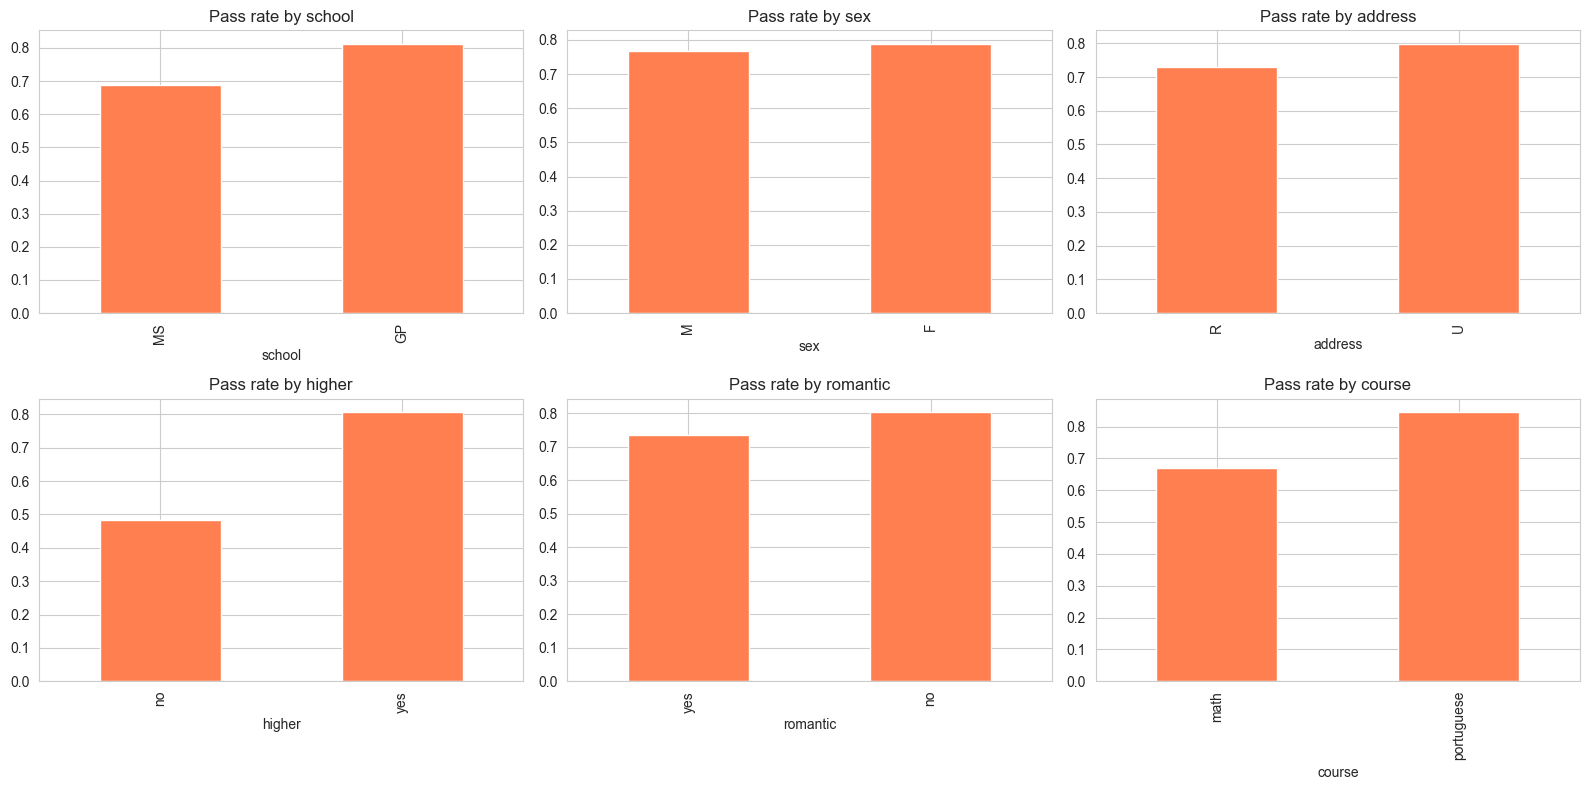

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(['school', 'sex', 'address', 'higher', 'romantic', 'course']):
    rate = df.groupby(col)['passed'].mean().sort_values()
    rate.plot(kind='bar', ax=axes[i], color='coral')
    axes[i].set_title(f'Pass rate by {col}')
plt.tight_layout(); plt.show()

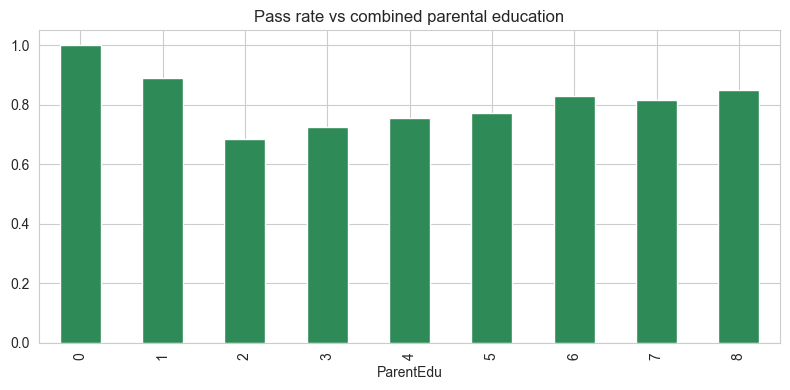

In [18]:
# Education effect: parental education vs pass
fig, ax = plt.subplots(figsize=(8, 4))
df['ParentEdu'] = df['Medu'] + df['Fedu']
df.groupby('ParentEdu')['passed'].mean().plot(kind='bar', ax=ax, color='seagreen')
ax.set_title('Pass rate vs combined parental education'); plt.tight_layout(); plt.show()

## 9. Pair Plot of Top Features

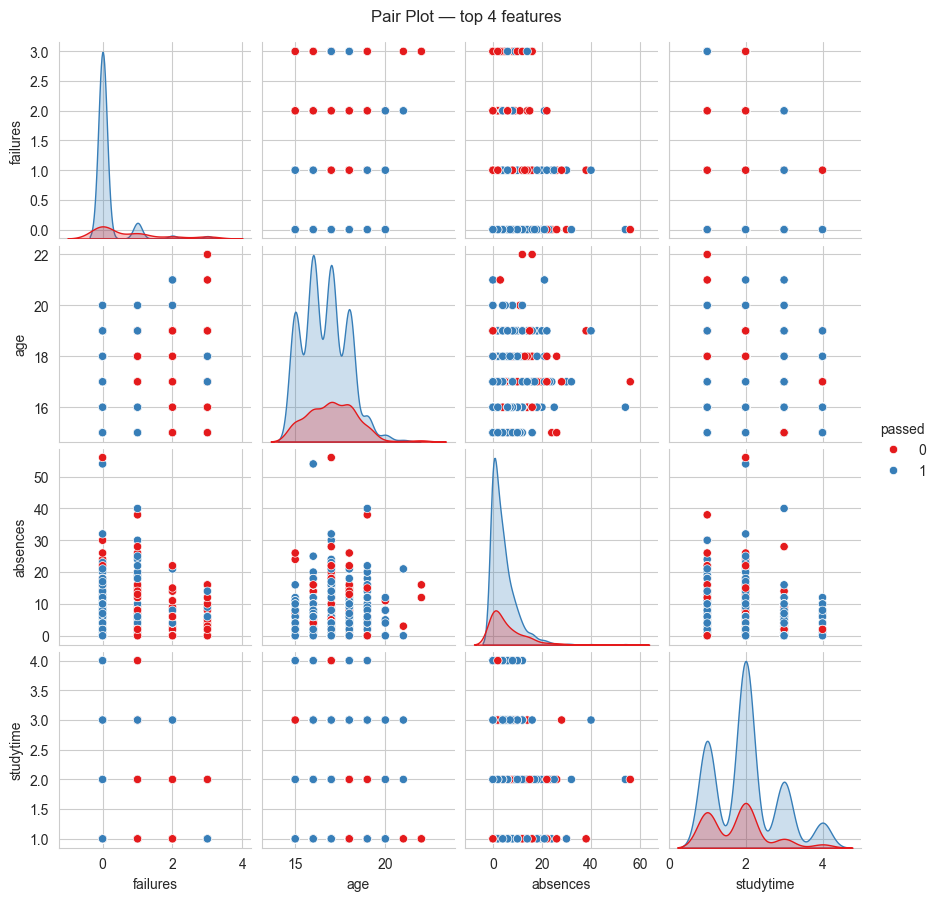

In [19]:
sample = df.sample(min(1000, len(df)), random_state=42)
sns.pairplot(sample[top_features[:4] + ['passed']].dropna(),
             hue='passed', palette='Set1', diag_kind='kde', height=2.2)
plt.suptitle('Pair Plot — top 4 features', y=1.02); plt.show()

## 10. Summary of Key Findings

In [20]:
summary = pd.DataFrame({
    'Metric': ['Total samples', 'Total features', 'Class 0 count', 'Class 1 count',
               'Class imbalance ratio', 'Top correlated feature', 'Top correlation value'],
    'Value': [
        len(df),
        df.shape[1] - 1,
        int((df['passed'] == 0).sum()),
        int((df['passed'] == 1).sum()),
        f"{(df['passed'] == 0).sum() / max(1, (df['passed'] == 1).sum()):.2f}:1",
        top_features[0],
        round(corrs_all[top_features[0]], 3),
    ],
})
summary

,Metric,Value
0,Total samples,1044
1,Total features,32
2,Class 0 count,230
3,Class 1 count,814
4,Class imbalance ratio,0.28:1
5,Top correlated feature,failures
6,Top correlation value,0.367
